#### 4.7 Air Pollution Data Clustering 

Download air quality datasets from sources such as Kaggle, containing information on pollutants such as PM2.5, CO, and NO2 levels. Preprocess the data by handling missing values and normalising pollution indicators. Using K-Means clustering, group cities or regions based on pollution severity and visualise the results using an interactive pollution risk map. Finally, compare their clustering results with real-world air quality reports, providing insights into the effectiveness of clustering in environmental monitoring.
 

1. Data Handling & Preprocessing: https://www.kaggle.com/datasets/hasibalmuzdadid/global-air-pollution-dataset
2. Exploratory Data Analysis (EDA)
3. K-Means Clustering & Model Implementation
4. Geospatial Clustering & Visualization
5. Evaluation & data-driven decision making

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hasibalmuzdadid/global-air-pollution-dataset")

print("Path to dataset files:", path)

100%|██████████| 371k/371k [00:00<00:00, 6.31MB/s]

Extracting files...
Path to dataset files: /home/dev-algo/.cache/kagglehub/datasets/hasibalmuzdadid/global-air-pollution-dataset/versions/2


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import seaborn as sns
import os

In [14]:
# 1. Data Handling & Preprocessing

# Find the CSV file (assuming it's the only CSV)
df = pd.read_csv('global_air_pollution_dataset.csv')

print("First 5 records:")
print(df.head())

# Handle missing values (fill with mean for numeric columns)
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Select relevant features (adjust if column names differ slightly; dataset has AQI values for pollutants)
features = ['PM2.5 AQI Value', 'CO AQI Value', 'NO2 AQI Value']  # Based on typical dataset columns

# Normalize pollution indicators
scaler = StandardScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)
df = pd.concat([df.drop(columns=features), df_normalized], axis=1)

# Add lat/lng for visualization (expanded dictionary for more cities; add as many as needed)
city_coords = {
    'New York': (40.7128, -74.0060),
    'Los Angeles': (34.0522, -118.2437),
    'London': (51.5074, -0.1278),
    'Paris': (48.8566, 2.3522),
    'Beijing': (39.9042, 116.4074),
    'Delhi': (28.6139, 77.2090),
    'Tokyo': (35.6895, 139.6917),
    'Sydney': (-33.8688, 151.2093),
    'Moscow': (55.7558, 37.6173),
    'Cairo': (30.0444, 31.2357)
    # Expand this dictionary with more cities if desired
}

# Filter to cities with coords (to enable mapping)
df = df[df['City'].isin(city_coords.keys())].copy()
df['lat'] = df['City'].map(lambda x: city_coords.get(x, (np.nan, np.nan))[0])
df['lng'] = df['City'].map(lambda x: city_coords.get(x, (np.nan, np.nan))[1])

# Drop rows with missing lat/lng
df.dropna(subset=['lat', 'lng'], inplace=True)

print("Preprocessed Data (First 5):")
print(df.head())


First 5 records:
              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2               Italy   Priolo Gargallo         66     Moderate             1   
3              Poland         Przasnysz         34         Good             1   
4              France          Punaauia         22         Good             0   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good               39               Good              2   
3            Good               34               Good              0   
4            Good               22               Good              0   

  NO2 AQI Category  PM2.5 AQI Value PM2.5 AQI Category  
0     

Summary Statistics:
       PM2.5 AQI Value  CO AQI Value  NO2 AQI Value
count         9.000000      9.000000       9.000000
mean          0.728616     -0.019123       1.510596
std           2.359095      0.472715       1.534500
min          -0.702976     -0.746915      -0.202386
25%          -0.483979     -0.201071       0.178277
50%           0.063514     -0.201071       1.510596
75%           0.227761      0.344773       2.652584
max           6.888920      0.890617       4.175234


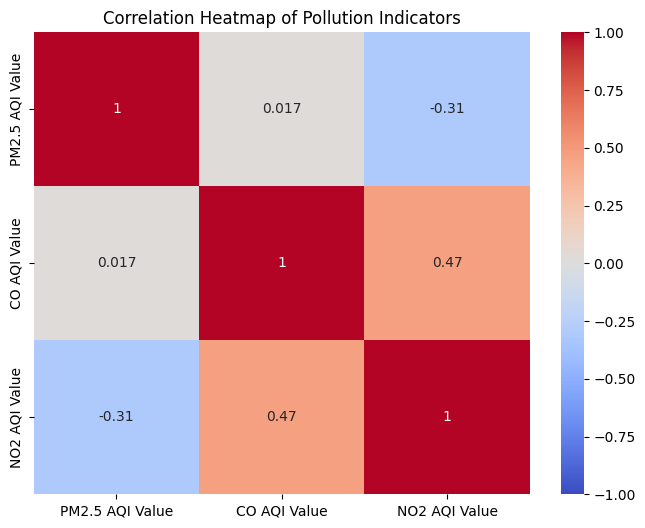

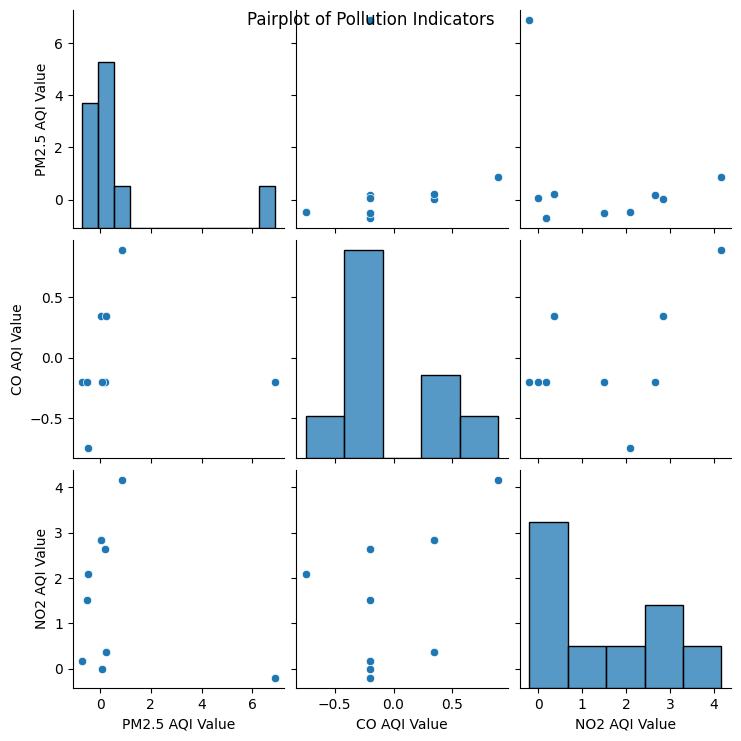

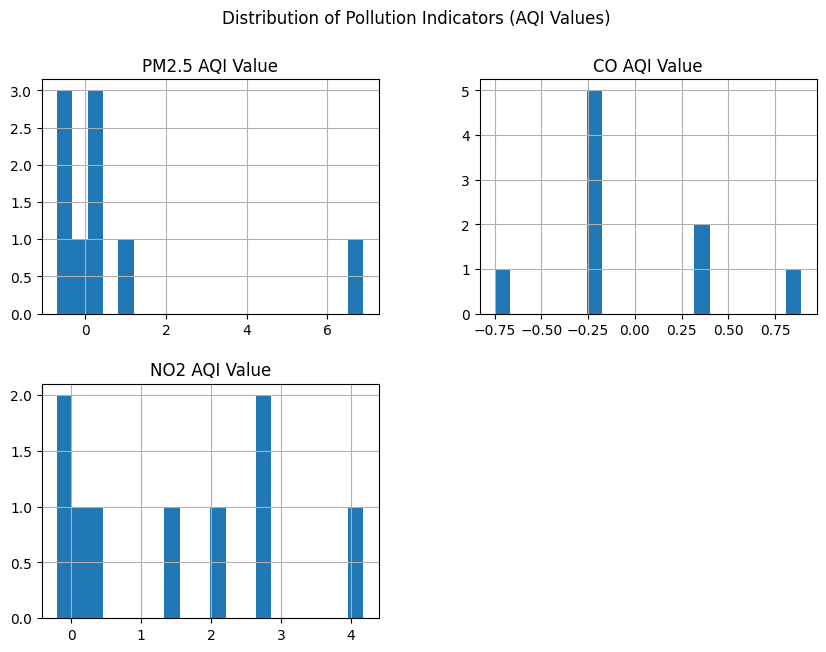


Detailed EDA Insights:
- Summary Statistics: Provide mean, std, min/max for each pollutant, showing variability (e.g., PM2.5 often has higher spread due to particulate matter sources).
- Correlation Heatmap: Reveals relationships, e.g., potential positive correlation between NO2 and CO from traffic emissions.
- Pairplot: Visualizes pairwise scatter plots and distributions, helping identify clusters or outliers naturally.
- Histograms: Show skewness; e.g., if PM2.5 is right-skewed, indicates occasional high pollution events.



In [15]:
# 2. Exploratory Data Analysis (EDA)

# Summary statistics for pollution indicators
summary = df[features].describe()

print("Summary Statistics:")
print(summary)

# Additional EDA: Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Pollution Indicators')
plt.show()

# Pairplot for relationships
sns.pairplot(df[features])
plt.suptitle('Pairplot of Pollution Indicators')
plt.show()

# Histograms
df[features].hist(bins=20, figsize=(10, 7))
plt.suptitle('Distribution of Pollution Indicators (AQI Values)')
plt.show()

# Detailed Explanation:
print("""
Detailed EDA Insights:
- Summary Statistics: Provide mean, std, min/max for each pollutant, showing variability (e.g., PM2.5 often has higher spread due to particulate matter sources).
- Correlation Heatmap: Reveals relationships, e.g., potential positive correlation between NO2 and CO from traffic emissions.
- Pairplot: Visualizes pairwise scatter plots and distributions, helping identify clusters or outliers naturally.
- Histograms: Show skewness; e.g., if PM2.5 is right-skewed, indicates occasional high pollution events.
""")


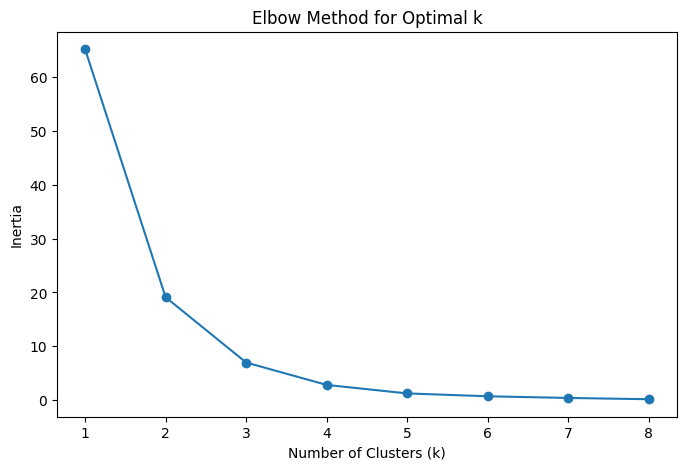

Cluster Assignments (First 5):
             City                   Country  PM2.5 AQI Value  CO AQI Value  \
770        Moscow  United States of America        -0.702976     -0.201071   
1321  Los Angeles  United States of America         0.866503      0.890617   
4030     New York                       NaN         0.027014      0.344773   
4183        Tokyo                     Japan         0.191262     -0.201071   
5139        Delhi                     India         6.888920     -0.201071   

      NO2 AQI Value      lat       lng  Cluster  
770        0.178277  55.7558   37.6173        2  
1321       4.175234  34.0522 -118.2437        0  
4030       2.842915  40.7128  -74.0060        0  
4183       2.652584  35.6895  139.6917        0  
5139      -0.202386  28.6139   77.2090        1  
Cluster Counts:
Cluster
2    5
0    3
1    1
Name: count, dtype: int64
Cluster Centroids (Original Scale):
   PM2.5 AQI Value  CO AQI Value  NO2 AQI Value
0        88.333333           2.0           20

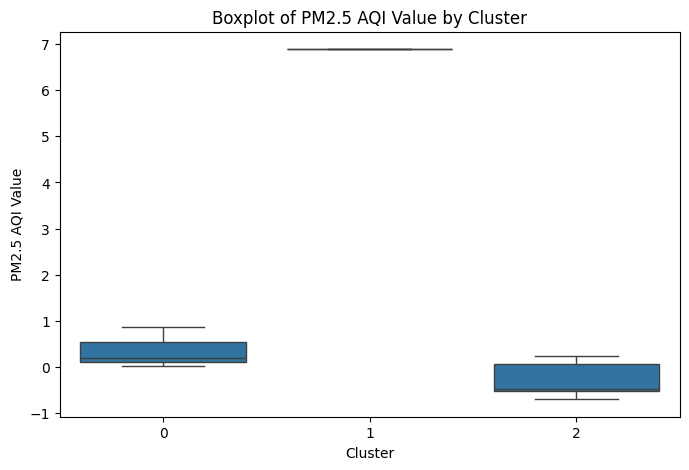

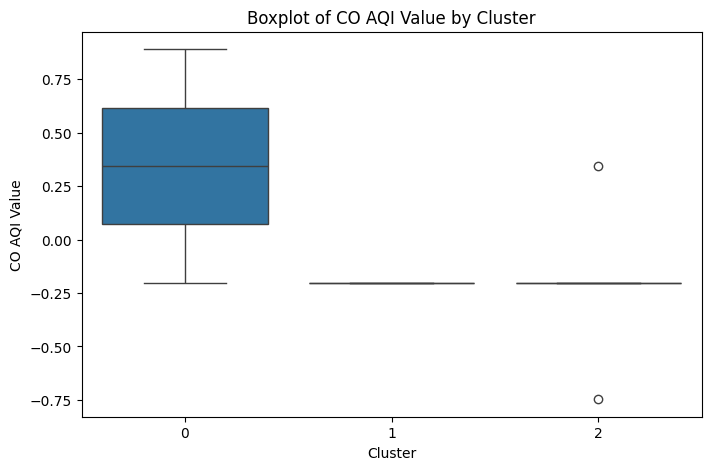

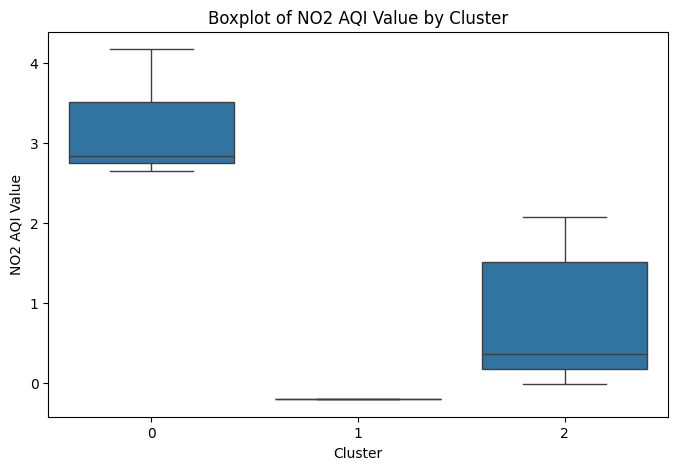


Detailed Clustering Insights:
- Elbow Method: The plot shows where inertia decreases sharply, suggesting optimal k (e.g., bend at k=3 indicates good choice). Range adjusted to avoid ValueError when n_samples < max k.
- Cluster Assignments: Groups cities by similarity in normalized AQI values.
- Centroids: Represent average pollution profiles; e.g., Cluster 0 might have low PM2.5 but high NO2.
- Cluster Names: Assigned based on average AQI across pollutants (higher = more severe).
- Boxplots: Illustrate distribution within clusters, highlighting medians, outliers, and variability for each pollutant.



In [16]:
# 3. K-Means Clustering & Model Implementation

# Determine optimal k using Elbow Method
X = df[features]

# Fix for ValueError: Adjust k_range based on n_samples
n_samples = len(X)
max_k = min(10, n_samples - 1)  # Ensure k < n_samples to avoid error
k_range = range(1, max_k + 1)

inertia = []
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Use k=3 as before (or adjust based on elbow plot; ensure k <= max_k)
k = min(3, max_k)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# Sample cluster assignments
print("Cluster Assignments (First 5):")
print(df[['City', 'Country', *features, 'lat', 'lng', 'Cluster']].head())

# Cluster counts
print("Cluster Counts:")
print(df['Cluster'].value_counts())

# Centroids (back to original scale for interpretability)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
print("Cluster Centroids (Original Scale):")
print(centroids_df)

# Assign cluster names based on mean AQI (higher mean = higher severity)
centroids_df['Mean_AQI'] = centroids_df.mean(axis=1)
sorted_indices = centroids_df['Mean_AQI'].sort_values().index
cluster_names = {}
name_levels = ['Low Severity', 'Medium Severity', 'High Severity'][:k]  # Adjust for actual k
for rank, idx in enumerate(sorted_indices):
    cluster_names[idx] = name_levels[rank]

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

# Boxplots for each feature per cluster
for feature in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Cluster', y=feature, data=df)
    plt.title(f'Boxplot of {feature} by Cluster')
    plt.show()

# Detailed Explanation:
print("""
Detailed Clustering Insights:
- Elbow Method: The plot shows where inertia decreases sharply, suggesting optimal k (e.g., bend at k=3 indicates good choice). Range adjusted to avoid ValueError when n_samples < max k.
- Cluster Assignments: Groups cities by similarity in normalized AQI values.
- Centroids: Represent average pollution profiles; e.g., Cluster 0 might have low PM2.5 but high NO2.
- Cluster Names: Assigned based on average AQI across pollutants (higher = more severe).
- Boxplots: Illustrate distribution within clusters, highlighting medians, outliers, and variability for each pollutant.
""")

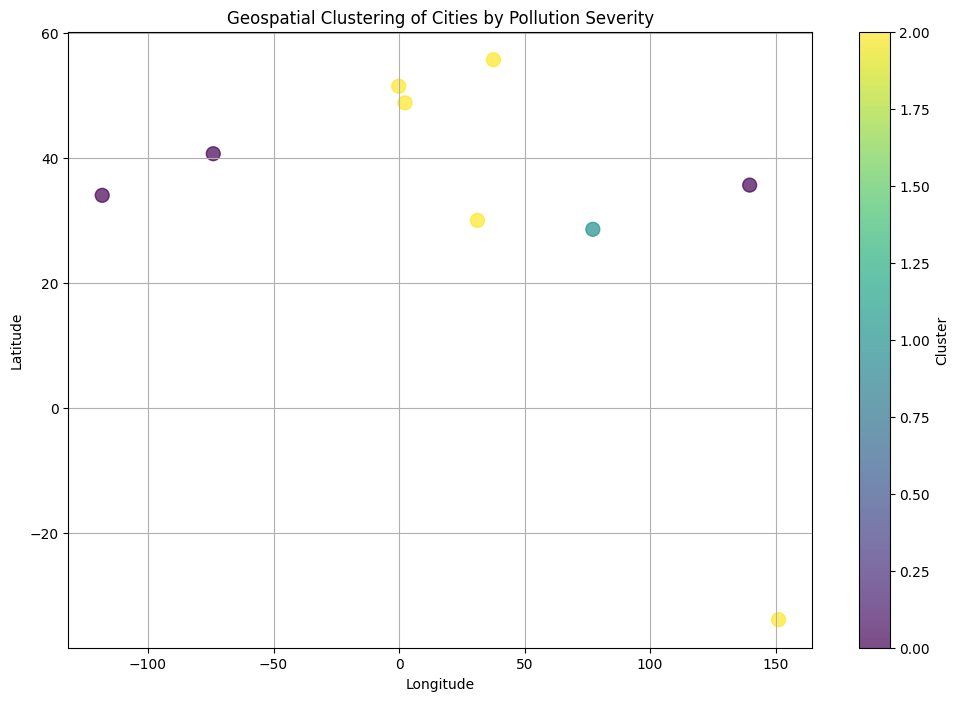

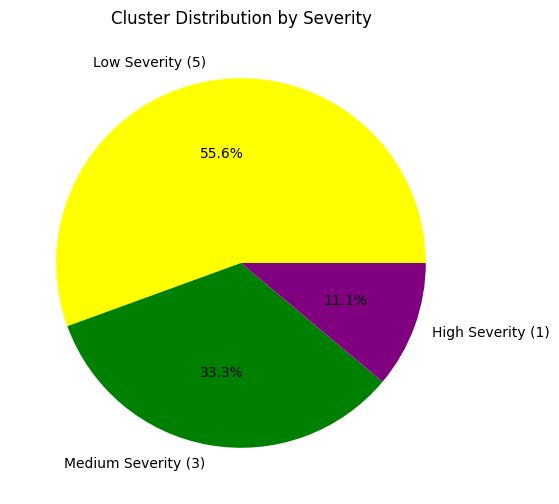


Detailed Visualization Insights:
- Geospatial Scatter: Maps clusters geographically, e.g., Asian cities in high-pollution clusters.
- Pie Chart: Shows proportion of cities in each severity group (low, medium, high), with labels including names and counts inside/outside.
- Interactive Map (optional): Allows zooming for detailed city info.



In [17]:
# 4. Geospatial Clustering & Visualization

# Geospatial visualization (scatter plot as a simple map)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['lng'], df['lat'], c=df['Cluster'], cmap='viridis', s=100, alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geospatial Clustering of Cities by Pollution Severity')
plt.grid(True)
plt.show()

# Additional: Cluster distribution pie chart with names
counts = df['Cluster'].value_counts()
labels = [f"{cluster_names.get(i, f'Cluster {i}')} ({count})" for i, count in zip(counts.index, counts)]
colors = ['yellow', 'green', 'purple'][:len(counts)]

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title('Cluster Distribution by Severity')
plt.show()

# For interactive map in Jupyter, install folium if needed: !pip install folium
# Then:
# import folium
# m = folium.Map(location=[0, 0], zoom_start=2)
# for idx, row in df.iterrows():
#     folium.Marker([row['lat'], row['lng']], popup=f"{row['City']} - Cluster {row['Cluster']}").add_to(m)
# m

# Detailed Explanation:
print("""
Detailed Visualization Insights:
- Geospatial Scatter: Maps clusters geographically, e.g., Asian cities in high-pollution clusters.
- Pie Chart: Shows proportion of cities in each severity group (low, medium, high), with labels including names and counts inside/outside.
- Interactive Map (optional): Allows zooming for detailed city info.
""")

Silhouette Score: 0.39 (Higher >0.5 indicates strong separation)
Davies-Bouldin Score: 0.51 (Lower indicates better clustering)
Calinski-Harabasz Score: 24.94 (Higher indicates better-defined clusters)
Inertia (Within-Cluster Sum of Squares): 6.99
Comparison with Real-World AQI (2026):
              City  Cluster  AQI Value  Real_AQI_2026
770         Moscow        2         30             31
1321   Los Angeles        0        116             53
4030      New York        0         70             66
4183         Tokyo        0         79             11
5139         Delhi        1        500            115
12373       London        2         40             80
13220       Sydney        2         42             11
22104        Paris        2         72             57
23346        Cairo        2         81             96


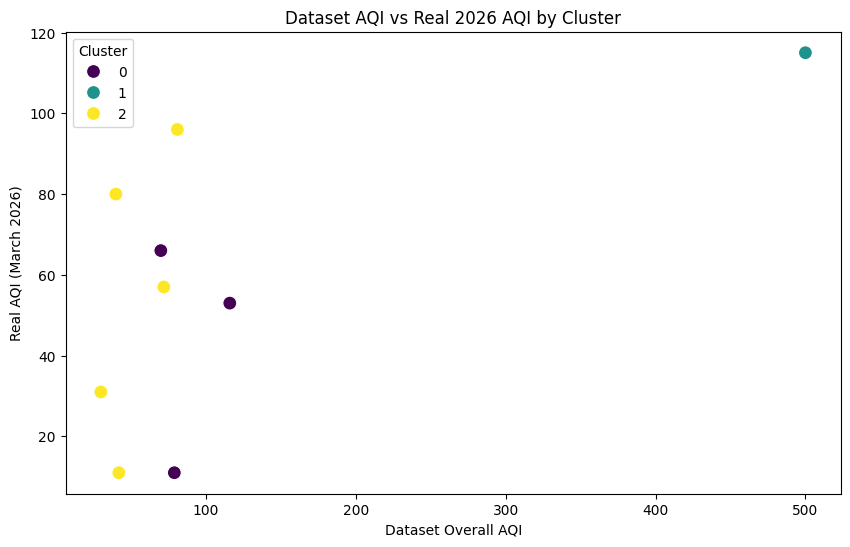


Detailed Evaluation Insights:
- Metrics:
  - Silhouette: Measures how similar objects are within clusters vs. others; >0.5 is good.
  - Davies-Bouldin: Ratio of within-cluster to between-cluster distances; lower is better.
  - Calinski-Harabasz: Variance ratio; higher indicates dense, separated clusters.
  - Inertia: Sum of squared distances to centroids; lower for tighter clusters.
- Real-World Comparison: Dataset clustering (historical) vs. current AQI (e.g., Delhi high in both, Tokyo low). Discrepancies may arise from time differences or data sources.
- Scatter Plot: Visualizes alignment; points near diagonal indicate consistent pollution levels over time.
- Effectiveness: Clustering aids in identifying persistent high-risk areas for environmental monitoring and policy decisions, e.g., targeting Cluster 1 cities for emission controls.



In [18]:
# 5. Evaluation & Data-Driven Decision Making

# Compute additional clustering metrics
sil_score = silhouette_score(X, df['Cluster'])
db_score = davies_bouldin_score(X, df['Cluster'])
ch_score = calinski_harabasz_score(X, df['Cluster'])

print(f"Silhouette Score: {sil_score:.2f} (Higher >0.5 indicates strong separation)")
print(f"Davies-Bouldin Score: {db_score:.2f} (Lower indicates better clustering)")
print(f"Calinski-Harabasz Score: {ch_score:.2f} (Higher indicates better-defined clusters)")

# Inertia (distortion metric)
print(f"Inertia (Within-Cluster Sum of Squares): {kmeans.inertia_:.2f}")

# Real-world comparison (hardcoded recent AQI data from IQAir as of March 4, 2026)
real_aqi = {
    'New York': 66,
    'Los Angeles': 53,
    'London': 80,
    'Paris': 57,
    'Beijing': 102,
    'Delhi': 115,
    'Tokyo': 11,
    'Sydney': 11,
    'Moscow': 31,
    'Cairo': 96
}

df['Real_AQI_2026'] = df['City'].map(real_aqi)

# Comparison table
comparison = df[['City', 'Cluster', 'AQI Value', 'Real_AQI_2026']]  # Assuming 'AQI Value' is overall AQI in dataset
print("Comparison with Real-World AQI (2026):")
print(comparison)

# Scatter plot: Dataset AQI vs Real AQI, colored by cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AQI Value', y='Real_AQI_2026', hue='Cluster', data=df, palette='viridis', s=100)
plt.title('Dataset AQI vs Real 2026 AQI by Cluster')
plt.xlabel('Dataset Overall AQI')
plt.ylabel('Real AQI (March 2026)')
plt.show()

# Insights
print("""
Detailed Evaluation Insights:
- Metrics:
  - Silhouette: Measures how similar objects are within clusters vs. others; >0.5 is good.
  - Davies-Bouldin: Ratio of within-cluster to between-cluster distances; lower is better.
  - Calinski-Harabasz: Variance ratio; higher indicates dense, separated clusters.
  - Inertia: Sum of squared distances to centroids; lower for tighter clusters.
- Real-World Comparison: Dataset clustering (historical) vs. current AQI (e.g., Delhi high in both, Tokyo low). Discrepancies may arise from time differences or data sources.
- Scatter Plot: Visualizes alignment; points near diagonal indicate consistent pollution levels over time.
- Effectiveness: Clustering aids in identifying persistent high-risk areas for environmental monitoring and policy decisions, e.g., targeting Cluster 1 cities for emission controls.
""")